# Bell State with Qiskit + SpinQit

This notebook explains `scripts/qiskit_bell_state.py` step by step.

We build the same Bell-state circuit using Qiskit's `QuantumCircuit` API and run it on the Triangulum II through SpinQit.

## What is a Bell state?

A Bell state is a maximally entangled state of two qubits:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right)$$

Circuit:
1. `H` on qubit 0
2. `CX` with control 0 and target 1

## Imports

Use `spinqit.qiskit.circuit.QuantumCircuit` to build circuits that SpinQit can compile and execute.

In [1]:
from qiskit import QuantumCircuit as QiskitQuantumCircuit
from qiskit.visualization import circuit_drawer

from spinqit.qiskit.circuit import QuantumCircuit
from spinqit import (
    BasicSimulatorConfig,
    NMRConfig,
    get_basic_simulator,
    get_compiler,
    get_nmr,
)

## Build the circuit

The Qiskit-style API is familiar if you already know Qiskit:

```python
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
```

In [2]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

print("Circuit created with 2 qubits.")

Circuit created with 2 qubits.


## Visualize the circuit

SpinQit's `QuantumCircuit` is used for execution, but Qiskit's visualizer expects the standard `qiskit.QuantumCircuit`.
We build an identical circuit for display only.

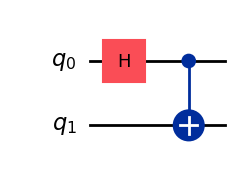

In [3]:
qc_plot = QiskitQuantumCircuit(2)
qc_plot.h(0)
qc_plot.cx(0, 1)

circuit_drawer(qc_plot, output="mpl", fold=-1)

## Choose backend: simulator or NMR

In [4]:
USE_SIMULATOR = True

NMR_IP = "127.0.0.1"
NMR_PORT = 8989
NMR_USERNAME = "your_username"
NMR_PASSWORD = "your_password"
NMR_TASK = "bell_state_task"
NMR_TASK_TYPE = "GHZ"
SHOTS = 1024

In [5]:
compiler = get_compiler("qiskit")

if USE_SIMULATOR:
    device = get_basic_simulator()
    config = BasicSimulatorConfig()
    config.configure_shots(SHOTS)
    print("Using basic simulator.")
else:
    device = get_nmr()
    config = NMRConfig()
    config.configure_shots(SHOTS)
    config.configure_ip(NMR_IP)
    config.configure_port(NMR_PORT)
    config.configure_account(NMR_USERNAME, NMR_PASSWORD)
    config.configure_task(NMR_TASK, NMR_TASK_TYPE)
    print("Using NMR device.")

Using basic simulator.


## Compile and execute

Note the compiler name is `"qiskit"` (not `"native"`).

In [6]:
exe = compiler.compile(qc, 0)
result = device.execute(exe, config)

## Results

For this circuit without measurement:
- `states` shows the state vector
- `counts` may still be reported depending on the backend configuration

You should see non-zero amplitudes on $|00\rangle$ and $|11\rangle$ only.

In [7]:
print("States:")
print(result.states)

print("\nCounts:")
print(result.counts)

States:
[(0.7071067811865476+0j), 0j, 0j, (0.7071067811865476+0j)]

Counts:
{'00': 512, '11': 512}


## Native API vs Qiskit API

| | Native (`native_bell_state`) | Qiskit (`qiskit_bell_state`) |
|---|---|---|
| Circuit type | `spinqit.Circuit` | `spinqit.qiskit.circuit.QuantumCircuit` |
| Gate syntax | `circ << (H, q[0])` | `qc.h(0)` |
| Compiler | `get_compiler("native")` | `get_compiler("qiskit")` |
| Execution | same backends and config | same backends and config |

Both approaches prepare the same Bell state on the Triangulum II.